## Practical 1 — From Real Biological Data to an ML-Ready Dataset
## Bladder cancer microarray data, data quality, grouping, and batch effects

## Learning goals

By the end of this practical, you should be able to:

- identify observations, features, metadata, targets, and technical variables in a real biological dataset;
- recognize the orientation and dimensionality of an expression matrix;
- apply tidy-data principles to biological measurements and metadata;
- perform systematic data diagnostics even when no obvious data-entry errors are present;
- transform a real expression dataset into an ML-ready representation;
- explain why repeated or highly related observations must remain in the same data split;
- distinguish **real batch structure** from an **artificial pseudo grouping**;
- detect evidence of batch effects and target–batch confounding;
- independently apply the same workflow to the UCI Mice Protein Expression dataset.

**Main idea:** a model sees numerical representations. It does not assume which variation is biological, technical, duplicated, or leaked across the train/test boundary.

# 0. Dataset check


We use the Bioconductor **`bladderbatch`** dataset: an Affymetrix microarray bladder-cancer dataset containing **57 samples, 22,283 probe-set expression measurements, and five processing batches**.

The Bioconductor metadata include:

- `sample` — sample number;
- `outcome` — original biological outcome;
- `batch` — processing batch defined by the date on which arrays were processed;
- `cancer` — a simplified biological outcome.

The expression data were RMA-normalized before inclusion in the package.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

DATA = Path(".")
RANDOM_STATE = 90926

In [ ]:
expression_raw = pd.read_csv(DATA / "bladder_expression_raw.csv")
metadata = pd.read_csv(DATA / "bladder_metadata.csv")


print("Raw expression:", expression_raw.shape)
print("Metadata:", metadata.shape)

Raw expression: (22283, 58)
Metadata: (57, 5)


In [ ]:
metadata

,sample_id,sample,outcome,batch,cancer
0,GSM71019.CEL,1,Normal,3,Normal
1,GSM71020.CEL,2,Normal,2,Normal
2,GSM71021.CEL,3,Normal,2,Normal
3,GSM71022.CEL,4,Normal,3,Normal
4,GSM71023.CEL,5,Normal,3,Normal
5,GSM71024.CEL,6,Normal,3,Normal
6,GSM71025.CEL,7,Normal,2,Normal
7,GSM71026.CEL,8,Normal,2,Normal
8,GSM71028.CEL,9,sTCC+CIS,5,Cancer
9,GSM71029.CEL,10,sTCC-CIS,2,Cancer


In [ ]:
expression_raw.head()

,probe_set_id,GSM71019.CEL,GSM71020.CEL,GSM71021.CEL,GSM71022.CEL,GSM71023.CEL,GSM71024.CEL,GSM71025.CEL,GSM71026.CEL,GSM71028.CEL,...,GSM71068.CEL,GSM71069.CEL,GSM71070.CEL,GSM71071.CEL,GSM71072.CEL,GSM71073.CEL,GSM71074.CEL,GSM71075.CEL,GSM71076.CEL,GSM71077.CEL
0,1007_s_at,10.115170,8.628044,8.779235,9.248569,10.256841,10.023133,9.108034,8.735616,9.803271,...,10.582892,10.009028,9.912853,9.096809,9.011927,8.396062,8.903465,9.501538,9.540766,9.039143
1,1053_at,5.345168,5.063598,5.113116,5.179410,5.181383,5.248418,5.252312,5.220931,5.595771,...,5.615926,5.151548,5.237126,5.093278,5.353248,5.214357,5.251383,5.223598,5.191392,5.235880
2,117_at,6.348024,6.663625,6.465892,6.116422,5.980457,5.796155,6.414849,6.846798,5.841478,...,5.913488,5.904794,5.960948,6.394089,6.425034,6.372520,6.095344,5.811968,6.007461,6.314809
3,121_at,8.901739,9.439977,9.540738,9.254368,8.798086,8.002870,9.093704,9.263386,7.789240,...,8.049998,8.407351,8.985741,8.817789,8.866083,8.704385,9.375736,8.580523,8.848099,9.663298
4,1255_g_at,3.967672,4.466027,4.144885,4.189338,4.078509,3.919740,4.402590,4.173666,3.590649,...,3.775194,3.995371,4.322380,4.141255,3.997644,4.219360,4.454771,4.188310,4.284053,4.877523


## 1.2 Prepare the expression matrix for scikit-learn

The raw export preserves the original assay orientation: probe sets are rows and biological samples are columns. Most scikit-learn workflows/tidy data principles expect the opposite orientation: samples are rows and features are columns.

We now transpose the matrix in Python and use the sample identifiers from the column names as `sample_id`. The resulting `expression` table is the ML-ready expression table used below.

In [ ]:
expression = expression_raw.set_index("probe_set_id").T.rename_axis("sample_id").reset_index()
expression.columns.name = None

print(expression_raw.shape)
print(expression.shape)


(22283, 58)
(57, 22284)


In [ ]:
expression

,sample_id,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,GSM71019.CEL,10.115170,5.345168,6.348024,8.901739,3.967672,7.775183,5.655863,4.855069,4.942097,...,5.889822,6.255983,11.772870,11.650434,4.295802,3.902905,3.396659,3.319554,3.637277,3.475397
1,GSM71020.CEL,8.628044,5.063598,6.663625,9.439977,4.466027,7.110154,6.068074,4.971663,4.892139,...,6.875853,6.832614,13.301387,13.092792,4.391424,3.725786,4.011382,3.477539,3.909711,3.710860
2,GSM71021.CEL,8.779235,5.113116,6.465892,9.540738,4.144885,7.248430,5.822590,4.955943,4.991248,...,5.400099,6.301081,13.682598,13.497060,4.380636,4.139661,3.799011,3.491621,3.885286,3.524983
3,GSM71022.CEL,9.248569,5.179410,6.116422,9.254368,4.189338,7.017220,5.659677,5.028884,5.163996,...,5.361622,5.519502,12.136462,11.808322,4.453195,3.838170,3.703706,3.392606,3.762326,3.783900
4,GSM71023.CEL,10.256841,5.181383,5.980457,8.798086,4.078509,7.896419,5.480801,4.838721,5.666031,...,6.549468,7.006766,11.918717,11.822269,4.298520,3.889372,3.530179,3.382881,3.777308,3.439520
5,GSM71024.CEL,10.023133,5.248418,5.796155,8.002870,3.919740,7.944676,5.141930,4.688610,5.635379,...,7.146261,7.351801,11.770457,11.609514,4.180763,3.888782,3.378287,3.341418,3.631794,3.438930
6,GSM71025.CEL,9.108034,5.252312,6.414849,9.093704,4.402590,7.469767,5.757393,5.063306,5.151760,...,4.971877,5.437525,13.252039,13.177725,4.418610,3.917813,3.769529,3.500478,3.928444,3.912421
7,GSM71026.CEL,8.735616,5.220931,6.846798,9.263386,4.173666,7.281925,6.134735,5.001731,4.634037,...,4.795820,5.289338,13.077570,13.140737,4.340074,3.765035,3.781147,3.620815,3.720592,3.591586
8,GSM71028.CEL,9.803271,5.595771,5.841478,7.789240,3.590649,7.367814,5.039009,4.629625,5.850502,...,5.016912,4.600464,10.553368,10.549932,3.866587,3.534812,3.188380,3.203602,3.363358,3.371751
9,GSM71029.CEL,10.168602,5.025180,6.352257,9.834564,4.338196,7.825735,5.571846,4.691905,4.697245,...,6.840086,6.829511,12.468495,12.425069,4.111634,3.859987,3.564584,3.407213,3.766254,3.692182


### First questions

Before doing any transformation, answer:

1. What is one **biological observation**?
2. What is a **feature**?
3. Which table contains biological measurements?
4. Which table contains experimental metadata?
5. Which column could be a prediction target?
6. Which column describes a known technical source of variation?

## 1.3 The dimensionality problem

In [ ]:
n_samples = expression.shape[0]
n_features = expression.shape[1] - 1

print("Samples:", n_samples)
print("Expression features:", n_features)
print("p / n =", round(n_features / n_samples, 1))

Samples: 57
Expression features: 22283
p / n = 390.9


In this dataset there are tens of thousands of measured variables but only dozens of biological samples.

This is extremely common in transcriptomics and other omics datasets.

> We are **not** solving the high-dimensional modelling problem today.

# 2. EDA and tidy-data principles

A useful working definition of tidy data is:

> **One observation per row, one variable per column, one value per cell.**


## 2.1 Inspect metadata

In [ ]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sample_id  57 non-null     object
 1   sample     57 non-null     int64 
 2   outcome    57 non-null     object
 3   batch      57 non-null     int64 
 4   cancer     57 non-null     object
dtypes: int64(2), object(3)
memory usage: 2.4+ KB


## 2.2 Inspect expression values

In [ ]:
gene_cols = [c for c in expression.columns if c != "sample_id"]

expression[gene_cols].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
1007_s_at,57.0,9.757507,0.627462,8.396062,9.287650,9.911038,10.256841,10.840534
1053_at,57.0,5.428176,0.247518,5.025180,5.237126,5.373810,5.587119,6.076057
117_at,57.0,6.197038,0.450471,5.211550,5.960948,6.116422,6.352257,8.477193
121_at,57.0,8.519904,0.541173,7.389635,8.158816,8.505293,8.866083,9.834564
1255_g_at,57.0,3.985271,0.241307,3.547688,3.824158,3.928739,4.141255,4.877523
1294_at,57.0,7.632357,0.452121,6.749402,7.288989,7.614454,7.952671,8.772693
1316_at,57.0,5.392179,0.320225,4.539403,5.172142,5.352646,5.571846,6.134735
1320_at,57.0,4.774995,0.230396,4.337072,4.638903,4.723609,4.874854,6.009317
1405_i_at,57.0,5.187052,0.844344,4.026040,4.643143,5.043862,5.531440,7.426352
1431_at,57.0,3.726263,0.371369,3.378088,3.564485,3.650139,3.776453,6.184132


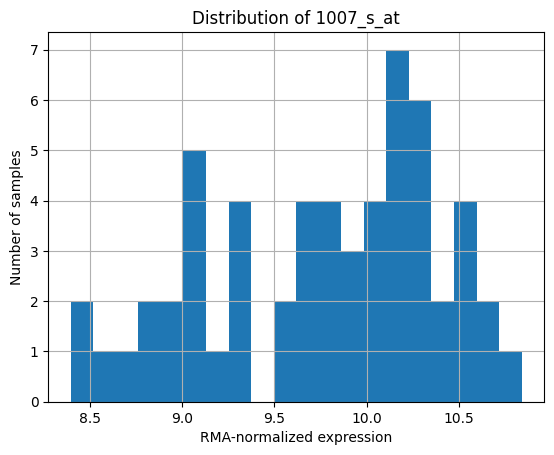

In [ ]:
expression[gene_cols[0]].hist(bins=20)
plt.xlabel("RMA-normalized expression")
plt.ylabel("Number of samples")
plt.title(f"Distribution of {gene_cols[0]}")
plt.show()

## 2.3 Biological outcome structure

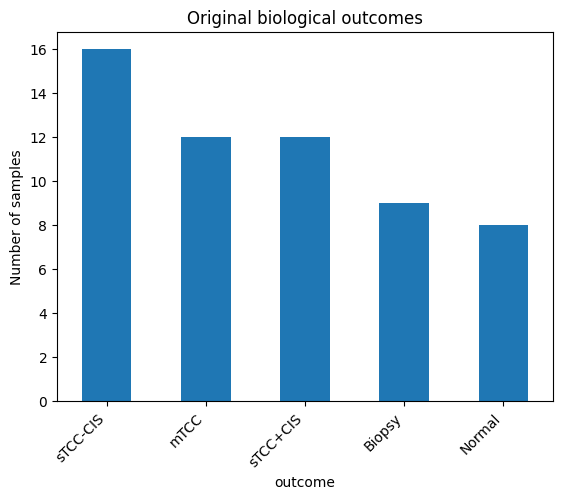

In [ ]:
metadata["outcome"].value_counts().plot(kind="bar")
plt.ylabel("Number of samples")
plt.title("Original biological outcomes")
plt.xticks(rotation=45, ha="right")
plt.show()

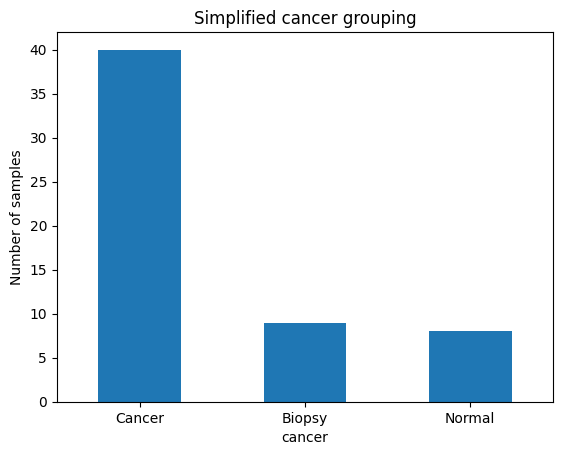

In [ ]:
metadata["cancer"].value_counts().plot(kind="bar")
plt.ylabel("Number of samples")
plt.title("Simplified cancer grouping")
plt.xticks(rotation=0)
plt.show()

### Discussion

Why might the original `outcome` and simplified `cancer` variables be useful for different questions?

# 3. Data diagnostics

A diagnostic workflow does **not** mean that we must discover corrupted data.

Real datasets should be checked systematically even when they appear clean.

## 3.1 Are sample identifiers unique?

In [ ]:
print("Expression IDs unique:", expression["sample_id"].is_unique)
print("Metadata IDs unique:", metadata["sample_id"].is_unique)

Expression IDs unique: True
Metadata IDs unique: True


## 3.2 Do both tables contain the same samples?

In [ ]:
expr_ids = set(expression["sample_id"])
meta_ids = set(metadata["sample_id"])

print("Expression only:", expr_ids - meta_ids)
print("Metadata only:", meta_ids - expr_ids)

Expression only: set()
Metadata only: set()


## 3.4 Exact duplicate samples

In [ ]:
print("Duplicate metadata rows:", metadata.duplicated().sum())
print("Duplicate expression rows:", expression.duplicated().sum())

Duplicate metadata rows: 0
Duplicate expression rows: 0


We can also ask whether any two expression rows are numerically identical.

In [ ]:
expr_only = expression.set_index("sample_id")
print("Duplicated expression profiles:",
      expr_only.duplicated().sum())

Duplicated expression profiles: 0


## 3.5 Constant and low-variance features

In [ ]:
variances = expression[gene_cols].var()

print("Constant features:", (variances == 0).sum())
print("Median feature variance:", variances.median())

Constant features: 0
Median feature variance: 0.1868963225451369


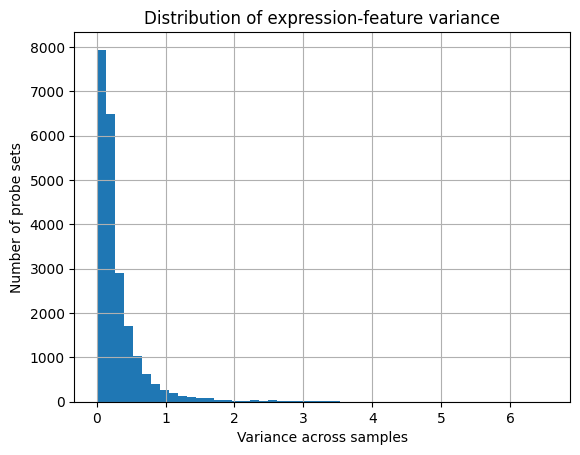

In [ ]:
variances.hist(bins=50)
plt.xlabel("Variance across samples")
plt.ylabel("Number of probe sets")
plt.title("Distribution of expression-feature variance")
plt.show()


# 4. Data preparation

## 4.1 Merge measurements and metadata

Because both tables should have one row per sample, we can enforce a one-to-one relationship.

In [ ]:
df_real = metadata.merge(
    expression,
    on="sample_id",
    validate="one_to_one")

print(df_real.shape)
df_real.iloc[:5, :10]



(57, 22288)


,sample_id,sample,outcome,batch,cancer,1007_s_at,1053_at,117_at,121_at,1255_g_at
0,GSM71019.CEL,1,Normal,3,Normal,10.115170,5.345168,6.348024,8.901739,3.967672
1,GSM71020.CEL,2,Normal,2,Normal,8.628044,5.063598,6.663625,9.439977,4.466027
2,GSM71021.CEL,3,Normal,2,Normal,8.779235,5.113116,6.465892,9.540738,4.144885
3,GSM71022.CEL,4,Normal,3,Normal,9.248569,5.179410,6.116422,9.254368,4.189338
4,GSM71023.CEL,5,Normal,3,Normal,10.256841,5.181383,5.980457,8.798086,4.078509


## 4.2 Define a possible target

For demonstration, we will use the simplified `cancer` variable as the candidate target.

In [ ]:
y_real = df_real["cancer"].copy()
y_real.value_counts()

,count
cancer,
Cancer,40
Biopsy,9
Normal,8


## 4.3 Define the real feature matrix

In [ ]:
X_real = df_real[gene_cols].copy()

print("X:", X_real.shape)
print("y:", y_real.shape)

X: (57, 22283)
y: (57,)


Notice what is **not** in `X_real`:

- `sample_id`;
- `sample`;
- `outcome`;
- `batch`;
- `cancer`.

Some are identifiers, one is our target, and others are metadata whose inclusion would change the scientific question.




# 5. Artificial within-group similarity for the splitting exercise

The original bladderbatch samples are real biological samples, but the dataset does not provide the repeated-subject structure we want for this exercise.

We will therefore construct **one pseudo-replicate per real sample** to intentioanlly spoil perfectly good dataset;)

For each real expression profile x_i, we create:

x_i_p = x_i + epsilon

epsilon - small noise

The pseudo-replicate is therefore **highly similar** to its source sample.

## 5.1 Generate pseudo-replicates

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

real = df_real.copy()
real["source_sample_id"] = real["sample_id"]
real["p_group"] = "TG_" + real["sample_id"].astype(str)


pseudo = df_real.copy()
pseudo["source_sample_id"] = pseudo["sample_id"]
pseudo["p_group"] = "TG_" + pseudo["sample_id"].astype(str)


# Give pseudo-replicates unique row/sample identifiers.
pseudo["sample_id"] = pseudo["sample_id"].astype(str) + "_pseudo"

# Small noise relative to the scale ofexpression.
noise_sigma = 0.25
noise = rng.normal(loc=0, scale=noise_sigma, size=(len(pseudo), len(gene_cols)))

pseudo.loc[:, gene_cols] = (pseudo[gene_cols].to_numpy() + noise)

df = pd.concat([real, pseudo], ignore_index=True)

print("Original samples:", len(real))
print("Pseudo-replicates:", len(pseudo))
print("pseudo rows:", len(df))
print("pseudo groups:", df["p_group"].nunique())

Original samples: 57
Pseudo-replicates: 57
pseudo rows: 114
pseudo groups: 57


### Important provenance rule

In [ ]:
df[["sample_id", "source_sample_id", "p_group",  "cancer", "batch"]].head(100)

,sample_id,source_sample_id,p_group,cancer,batch
0,GSM71019.CEL,GSM71019.CEL,TG_GSM71019.CEL,Normal,3
1,GSM71020.CEL,GSM71020.CEL,TG_GSM71020.CEL,Normal,2
2,GSM71021.CEL,GSM71021.CEL,TG_GSM71021.CEL,Normal,2
3,GSM71022.CEL,GSM71022.CEL,TG_GSM71022.CEL,Normal,3
4,GSM71023.CEL,GSM71023.CEL,TG_GSM71023.CEL,Normal,3
...,...,...,...,...,...
95,GSM71059.CEL_pseudo,GSM71059.CEL,TG_GSM71059.CEL,Cancer,2
96,GSM71060.CEL_pseudo,GSM71060.CEL,TG_GSM71060.CEL,Cancer,1
97,GSM71061.CEL_pseudo,GSM71061.CEL,TG_GSM71061.CEL,Cancer,5
98,GSM71062.CEL_pseudo,GSM71062.CEL,TG_GSM71062.CEL,Cancer,5


`source_sample_id`, and `p_group` are synthetic metadata.

The original `batch`, `outcome`, and `cancer` values remain those of the real sample.

## 5.2 Verify within-group similarity

Calculate the correlation between every real sample and its pseudo-replicate.

In [ ]:
pair_correlations = []

for group, group_df in df.groupby("p_group"):
    if len(group_df) != 2:
        continue

    a = group_df.iloc[0][gene_cols].to_numpy(dtype=float)
    b = group_df.iloc[1][gene_cols].to_numpy(dtype=float)

    pair_correlations.append(np.corrcoef(a, b)[0, 1])

pair_correlations = pd.Series(pair_correlations)

pair_correlations

,0
0,0.988718
1,0.984992
2,0.985270
3,0.986737
4,0.988647
5,0.990366
6,0.985937
7,0.986012
8,0.991325
9,0.987664


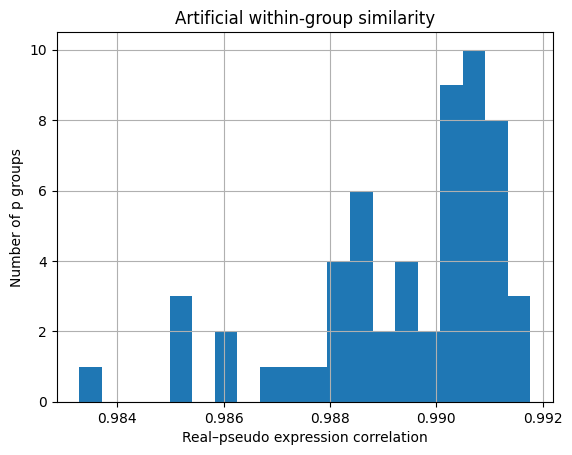

In [ ]:
pair_correlations.hist(bins=20)
plt.xlabel("Real–pseudo expression correlation")
plt.ylabel("Number of p groups")
plt.title("Artificial within-group similarity")
plt.show()

## 5.3 Introduce synthetic missing values (pseudoNA)
To spoil our good dataset even more we will intoduce some NA.
We alter expression measurements only; sample identifiers, metadata, targets, and grouping variables remain available for the exercise.

In [ ]:
pseudo_na_rng = np.random.default_rng(RANDOM_STATE + 1)

df_pseudona = df.copy()
expression_values = df_pseudona[gene_cols].to_numpy(dtype=float).copy()

# Remove 0.01% of expression cells

pseudo_na_fraction = 0.0001
n_expression_cells = expression_values.size
n_pseudona = max(1, int(round(n_expression_cells * pseudo_na_fraction)))
flat_indices = pseudo_na_rng.choice(
    n_expression_cells,
    size=n_pseudona,
    replace=False
)
rows, columns = np.unravel_index(
    flat_indices,
    expression_values.shape
)
expression_values[rows, columns] = np.nan
df_pseudona.loc[:, gene_cols] = expression_values

print("pseudo rows:", len(df_pseudona))
print("Synthetic missing expression cells:", df_pseudona[gene_cols].isna().sum().sum())

pseudo rows: 114
Synthetic missing expression cells: 254


## 5.4 Missing-value handling: detection, removal, and imputation

Missing values should be handled as part of the data-generating and modelling workflow. Start by detecting where they occur and how much information is affected.

There is no universally correct response:

- **Detection:** inspect missingness by table, row, column, and experimental group.
- **Removal:** remove rows or features only when the loss is acceptable and the rule is scientifically justified. In high-dimensional data, dropping every row with any missing feature can discard most observations.
- **Imputation:** replace missing values using a rule such as a median, mean, K-nearest neighbours, or a model-based method. The imputation rule must be fitted on the training data only, then applied to the test data, so that test-set information does not leak into training.

The following cells are a demonstration using the synthetic pseudoNA copy.

In [ ]:
missing_by_column = df_pseudona[gene_cols].isna().sum()
missing_by_row = df_pseudona[gene_cols].isna().sum(axis=1)

print("Total missing expression cells:", int(missing_by_column.sum()))
print("Features with at least one missing value:", int((missing_by_column > 0).sum()))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))

display(missing_by_column[missing_by_column > 0].head())
missing_by_row.describe()

Total missing expression cells: 254
Features with at least one missing value: 253
Rows with at least one missing value: 104


,0
179_at,1
200073_s_at,1
200091_s_at,1
200737_at,1
200824_at,1


,0
count,114.000000
mean,2.228070
std,1.343849
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


### Removal as a possible strategy

Complete-row removal is easy to write, but it can be very costly. Feature removal is another option, although removing a feature because of one missing value may also discard useful measurements. Compare both consequences before choosing a rule.

In [ ]:
df_rows_removed = df_pseudona.dropna(subset=gene_cols)
features_without_missing = [
    column for column in gene_cols
    if df_pseudona[column].notna().all()
]
X_features_removed = df_pseudona[features_without_missing].copy()

print("Rows before removal:", len(df_pseudona))
print("Rows after complete-row removal:", len(df_rows_removed))
print("Features before removal:", len(gene_cols))
print("Features after removal of any incomplete feature:", X_features_removed.shape[1])

Rows before removal: 114
Rows after complete-row removal: 10
Features before removal: 22283
Features after removal of any incomplete feature: 22030


### Imputation as a possible strategy

Here we use median imputation as a simple baseline. In a real analysis, the choice should reflect the measurement process and the scientific question.

In [ ]:

X_pseudona = df_pseudona[gene_cols].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_pseudona), columns=gene_cols)


X_imputed.isna().sum().sum()

np.int64(0)

# 6. Splits

## 6.1 Naive random row-wise split

In [ ]:
row_indices = np.arange(len(df))

train_idx_random, test_idx_random = train_test_split(
    row_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["cancer"])

random_train = df.iloc[train_idx_random]
random_test = df.iloc[test_idx_random]

Lets check if some pseudo groups is present in both sets

In [ ]:
random_train_groups = set(random_train["p_group"])
random_test_groups = set(random_test["p_group"])

leaked_groups = random_train_groups & random_test_groups

print("Groups appearing in both train and test", len(leaked_groups))

list(sorted(leaked_groups))

Groups appearing in both train and test 23


['TG_GSM71019.CEL',
 'TG_GSM71020.CEL',
 'TG_GSM71030.CEL',
 'TG_GSM71031.CEL',
 'TG_GSM71032.CEL',
 'TG_GSM71033.CEL',
 'TG_GSM71034.CEL',
 'TG_GSM71035.CEL',
 'TG_GSM71036.CEL',
 'TG_GSM71042.CEL',
 'TG_GSM71043.CEL',
 'TG_GSM71044.CEL',
 'TG_GSM71046.CEL',
 'TG_GSM71052.CEL',
 'TG_GSM71053.CEL',
 'TG_GSM71054.CEL',
 'TG_GSM71061.CEL',
 'TG_GSM71065.CEL',
 'TG_GSM71066.CEL',
 'TG_GSM71067.CEL',
 'TG_GSM71074.CEL',
 'TG_GSM71075.CEL',
 'TG_GSM71076.CEL']

These rows are not independent. A pseudo-replicate in the test set may be almost identical to its source sample in training.


## 6.2 Group-aware split

In [ ]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE)

train_idx, test_idx = next(
    splitter.split(
        df[gene_cols],
        df["cancer"],
        groups=df["p_group"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

In [ ]:
train_groups = set(train_df["p_group"])
test_groups = set(test_df["p_group"])

print("Group overlap", train_groups & test_groups)

Group overlap set()


Expected:

```text
set()
```

## 6.3 Verify that each original/pseudo pair stays together

In [ ]:
split_membership = pd.Series("test", index=df.index)
split_membership.iloc[train_idx] = "train"

check = (
    df.assign(split=split_membership)
      .groupby("p_group")["split"]
      .nunique())

print("Groups split across partitions",(check > 1).sum())

Groups split across partitions 0


### Discussion

For the artificial pseud data, `p_group` plays the role that variables such as these often play in real studies:

- patient ID;
- donor ID;
- animal ID;
- family;
- experimental unit;
- repeated-measure subject;
- original image before augmentation;
- original molecule before generating conformers.

# 7. Real batch effects and confounding

Now we return to a property that is **not synthetic**.

`batch` is real metadata from the bladderbatch experiment and reflects the dates on which microarrays were processed.

## 7.1 Examine the experimental design

Use **only the real samples** here so that our pseudo-replicates do not alter counts.

In [ ]:
pd.crosstab(real["batch"], real["cancer"],margins=True)

cancer,Biopsy,Cancer,Normal,All
batch,,,,
1,0,11,0,11
2,0,14,4,18
3,0,0,4,4
4,5,0,0,5
5,4,15,0,19
All,9,40,8,57


In [ ]:
pd.crosstab(real["batch"], real["cancer"], normalize="index").round(2)

cancer,Biopsy,Cancer,Normal
batch,,,
1,0.00,1.00,0.00
2,0.00,0.78,0.22
3,0.00,0.00,1.00
4,1.00,0.00,0.00
5,0.21,0.79,0.00


### Question

Is biological class independent of processing batch?

## 7.2 Original outcomes by batch

In [ ]:
outcome_batch = pd.crosstab(real["batch"], real["outcome"])

outcome_batch

outcome,Biopsy,Normal,mTCC,sTCC+CIS,sTCC-CIS
batch,,,,,
1,0,0,11,0,0
2,0,4,1,0,13
3,0,4,0,0,0
4,5,0,0,0,0
5,4,0,0,12,3


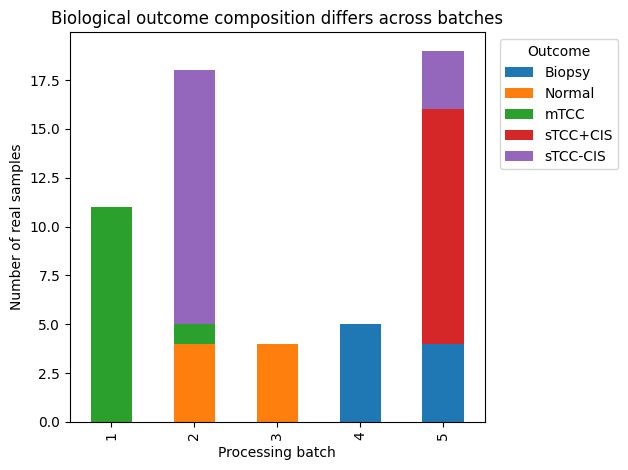

In [ ]:
outcome_batch.plot(kind="bar", stacked=True)

plt.xlabel("Processing batch")
plt.ylabel("Number of real samples")
plt.title("Biological outcome composition differs across batches")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 8. Visualizing batch structure

We will use PCA only as a **diagnostic visualization** here.

The mathematical details of PCA will be covered in a later practical.

## 8.1 Select highly variable features for visualization

Using all 22,283 features is unnecessary for a quick exploratory plot. So we will keep only top 1000 by variation

In [ ]:
real_X = real[gene_cols]

feature_variance = real_X.var().sort_values(ascending=False)
top_genes = feature_variance.head(1000).index

X_vis = real_X[top_genes]

## 8.2 Standardize and project to two dimensions

In [ ]:
X_scaled = StandardScaler().fit_transform(X_vis)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "batch": real["batch"].astype(str).values,
    "cancer": real["cancer"].astype(str).values,
    "outcome": real["outcome"].astype(str).values
})

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)

Explained variance: [0.279 0.166]


## 8.3 Color by batch

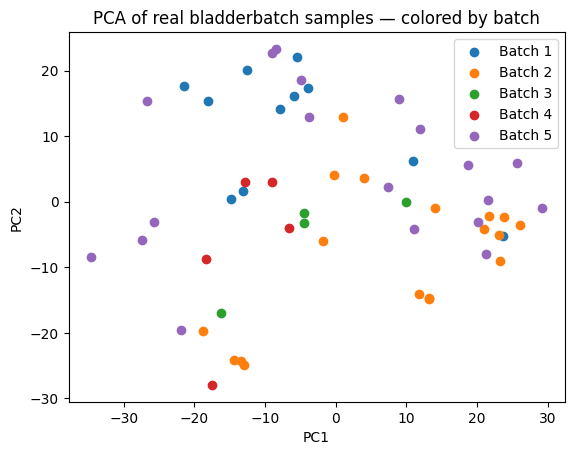

In [ ]:
for batch, group in pca_df.groupby("batch"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=f"Batch {batch}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of real bladderbatch samples — colored by batch")
plt.legend()
plt.show()

## 8.4 Color by cancer class

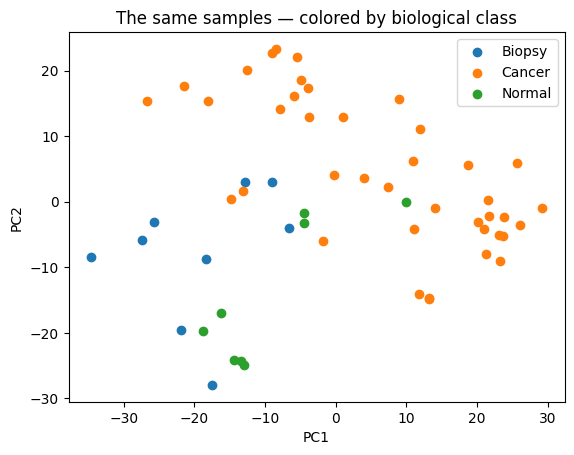

In [ ]:
for label, group in pca_df.groupby("cancer"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("The same samples — colored by biological class")
plt.legend()
plt.show()

### Discussion

Look at the **same geometric arrangement** twice:

1. colored by processing batch;
2. colored by biological target.

If batch and target are associated, how confidently can we interpret a predictive signal as biology?

# 9. Prepare ML-ready train and test sets

Return to the group-aware split.

In [ ]:
X_train = train_df[gene_cols].copy()
X_test = test_df[gene_cols].copy()

y_train = train_df["cancer"].copy()
y_test = test_df["cancer"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (84, 22283)
X_test: (30, 22283)
y_train: (84,)
y_test: (30,)


Check missingness before proceeding.

In [ ]:
print("Missing train values:",
      X_train.isna().sum().sum())

print("Missing test values:",
      X_test.isna().sum().sum())

Missing train values: 0
Missing test values: 0


At this point we have demonstrated how an ML-ready dataset is constructed.

We deliberately stop before fitting a predictive model.

# 10. What was real and what was synthetic?

| Component | Provenance | Purpose |
|---|---|---|
| Microarray expression | **Real** | Biological measurement |
| `outcome` | **Real** | Original biological class |
| `cancer` | **Real** | Simplified biological class |
| `batch` | **Real** | Processing batch |
| 57 original samples | **Real** | Biological observations |
| Pseudo-replicate expression | **Synthetic derivative** | Grouping/leakage demonstration |
| `p_group` | **Synthetic** | Group-aware splitting |
| `replicate_type` | **Synthetic** | Track provenance |



# 11. Independent task - UCI Mice Protein Expression



Now apply the same general workflow to the UCI Mice Protein Expression dataset.

The instructor will provide:

    Data_Cortex_Nuclear.xls

The dataset is available from the UCI Machine Learning Repository at:
https://archive.ics.uci.edu/dataset/342/mice%2Bprotein%2Bexpression

The dataset contains 1,080 rows, expression levels for 77 proteins or protein modifications, measurements from 72 mice, and 15 measurements per mouse. It also includes MouseID, Genotype, Treatment, Behavior, and an eight-level composite class.

For this practical, treat MouseID as the independent biological unit when asking whether a model generalizes to new mice. The repeated measurements from one mouse must stay in the same partition. The UCI dataset also contains real missing values, so your workflow must make the NA decision explicit.

Your goal is to turn the data into a defensible ML-ready dataset while keeping measurement, mouse, experimental-condition, and target roles separate.



## Required tasks



### A. Data presentation

Identify:

- what one row represents and what one biological mouse represents;
- the 77 numerical protein-expression measurements;
- MouseID and the experimental metadata;
- one possible prediction target.

Consider Genotype as a primary target: control versus trisomy. You may choose the eight-level class target instead, but explain why. Remember that class is constructed from genotype, behavior, and treatment.

### B. EDA and tidy-data assessment

- load the Excel file and inspect dimensions, column names, and data types;
- inspect the distributions of Genotype, Treatment, Behavior, and class;
- check how many rows and how many unique mice belong to each group;
- visualize at least three biologically meaningful relationships.

Possible plots include:

- distributions of selected protein measurements by genotype;
- a PCA or two-dimensional projection colored by genotype, treatment, or behavior;
- protein-expression relationships or a correlation heatmap;
- the number of measurements per MouseID.

For every plot, state the biological question it addresses.

### C. Diagnostics

Check:

- missingness in the protein measurements and metadata;
- duplicate rows and duplicate MouseID-measurement records;
- whether every mouse has the expected number of repeated measurements;
- unusual categories or inconsistent labels;
- non-finite, negative, or otherwise implausible expression values;
- highly correlated or redundant protein variables;
- whether any candidate predictor is a deterministic part of the target.

### D. Preparation

Choose one supervised-learning problem and create:

    X
    y

Explain every variable that you exclude.

For a genotype-prediction question, start with the 77 protein measurements as candidate features. Exclude:

- MouseID, because it identifies the biological unit and can cause leakage;
- the target column;
- class when Genotype is the target, because it contains genotype information;
- Treatment and Behavior unless you explicitly want a conditional prediction question and can justify their use.

Use the real missing values in the dataset to compare a defensible removal rule with an imputation rule. If you impute, fit the imputer on the training data only and apply it to the test data.

### E. Split

Create an appropriate training/test split.

For generalization to unseen mice:

- group by MouseID;
- keep all 15 measurements from a mouse in the same partition;
- use a group-aware split such as GroupShuffleSplit or StratifiedGroupKFold when appropriate.

Explain:

- what population you want the model to generalize to;
- why a row-wise random split would give an over-optimistic estimate;
- what the independent biological unit is;
- whether stratification is needed and whether it is compatible with your grouping strategy.

### F. Confounding and distribution structure

Investigate associations between the target and:

- treatment;
- behavior;
- genotype;
- the composite class;
- the number of measurements per mouse.

Use cross-tabulations and plots to ask:

- are treatment and behavior balanced across genotype?
- does the composite class encode the target directly?
- do some mice or experimental groups contribute different numbers of rows?
- could a model exploit experimental design structure instead of protein biology?

Identify at least one plausible source of confounding, target leakage, or distribution shift.

### G. Deliverable

Provide:

- X_train, X_test, y_train, y_test;
- a table documenting the role of each column;
- a missingness report and a justified removal or imputation decision;
- plots if you want;
- a short Markdown interpretation describing:
  - the ML question;
  - the biological unit;
  - the split strategy;
  - one potential source of bias, confounding, or leakage.

## Optional advanced task

Compare two evaluation questions:

1. a random row-wise train/test split;
2. a mouse-grouped train/test split.

Are these evaluating the same kind of generalization?

As a second extension, compare predicting Genotype with predicting the composite class. Which question is biologically clearer, and which variables must be excluded to avoid target leakage?




# 12. Take-home messages



- Biological data should be understood before they are modelled.
- High-dimensional omics commonly have \(p \gg n\).
- Metadata are part of the scientific problem, not administrative decoration.
- Data diagnostics include checking experimental structure, not only detecting `NaN`.
- Similar or repeated observations must remain in the same split.
- Data augmentation and pseudo-replication can produce leakage if derivatives cross the split boundary.
- Batch effects are technical signals that a model can exploit.
- Batch–target confounding makes biological interpretation especially difficult.
- Train/test splitting is part of experimental design.
- A valid ML pipeline begins with a valid scientific question.

# 13. Data-preparation readiness checklist



Use this checklist before starting any biological machine-learning analysis. Tick an item only after inspecting the data or documenting a justified decision. It is dataset-independent and can be reused in later practicals.

## Scientific purpose and provenance

- [*] Is the biological question and prediction task stated clearly?
- [*] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)?
- [*] Do I know where the data came from, how they were generated, and under which license or access conditions they may be used?
- [*] Have I recorded the data version, processing history, and transformations already applied?

## Table shape and identifiers

- [*] Is the table tidy: one observation per row, one variable per column, and one value per cell?
- [*] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool?
- [*] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns?
- [*] Can every feature and observation be traced back to its source?
- [*] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order?

## Types, values, and measurement meaning

- [*] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
- [*] Are units, scales, encodings, reference categories, and detection limits understood?
- [*] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?
- [*] Are normalization, scaling, log transformation, and batch-correction steps documented?

## Missing values

- [*] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
- [*] Have I measured missingness by row, column, group, and relevant batch or time variable?
- [*] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
- [*] Have I justified whether to retain, remove, or impute missing values?
- [*] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?

## Replicates, dependence, and grouping

- [*] Have I checked for exact duplicates and near-duplicate observations?
- [*] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [*] Is the independent biological unit identified by a grouping variable?
- [*] Will all related observations and their derivatives remain in the same train/validation/test split?
- [*] If I created augmented or synthetic observations, is their provenance recorded and reproducible?

## Target, leakage, and study design

- [*] Is the target defined before modelling, with its classes or values checked for balance and validity?
- [*] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
- [*] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
- [*] Have I checked whether the target is associated with a technical or grouping variable?
- [*] Does the planned split represent the biological generalization question?

## Reproducibility and decision record

- [*] Are random seeds, software versions, file names, and input/output shapes recorded?
- [*] Are all preprocessing steps placed in a reproducible pipeline?
- [*] Have I recorded unresolved data-quality concerns and the decisions made about them?
- [*] Can another person explain what each row, column, feature, target, and grouping variable means?

## Short preparation summary

Before modelling, write down:

- biological unit: the individual mouse (Mouse_Unit)
- number of observations and features: 1080 observations and 82 total features (77 used as protein features)
- target and feature definition: target is Genotype, features are 77 protein expression levels
- missing-value decision: median imputation fitted on train data (dropping rows loses too much information)
- replicate/grouping decision: grouped by Mouse_Unit to keep all 15 measurements of the same mouse together
- main confounder or possible leakage source: class column (target leakage) and MouseID (data leakage)
- train/test split and why it is appropriate: GroupShuffleSplit, because it prevents data leakage by keeping technical replicates of the same mouse strictly in either train or test set
- remaining concerns: uneven number of mice across different experimental cohorts

# Independent task: Completion

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

## Required tasks


### A. Data presentation

Identify:

- what one row represents and what one biological mouse represents;
  - a row: single technical measurementb
  - biological mouse: the independent unit containing 15 such measurements
- the 77 numerical protein-expression measurements;
  - they are the numerical features representing the expression levels of specific proteins
- MouseID and the experimental metadata;
  - MouseID: sample identifier
  - experimental metadata: consists of Genotype, Treatment, Behavior, and class
- one possible prediction target.
  - Genotype is the primary target because predicting the composite class would cause target leakage

Consider Genotype as a primary target: control versus trisomy. You may choose the eight-level class target instead, but explain why. Remember that class is constructed from genotype, behavior, and treatment.




### B. EDA and tidy-data assessment



- load the Excel file and inspect dimensions, column names, and data types;
- inspect the distributions of Genotype, Treatment, Behavior, and class;
- check how many rows and how many unique mice belong to each group;
- visualize at least three biologically meaningful relationships.

Possible plots include:

- distributions of selected protein measurements by genotype;
- a PCA or two-dimensional projection colored by genotype, treatment, or behavior;
- protein-expression relationships or a correlation heatmap;
- the number of measurements per MouseID.

For every plot, state the biological question it addresses.

In [ ]:
df=pd.read_excel('Data_Cortex_Nuclear.xls')

In [ ]:
df

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,J3295_11,0.254860,0.463591,0.254860,2.092082,2.600035,0.211736,0.171262,2.483740,0.207317,...,0.183324,0.374088,0.318782,0.204660,0.328327,1.364823,Ts65Dn,Saline,S/C,t-SC-s
1076,J3295_12,0.272198,0.474163,0.251638,2.161390,2.801492,0.251274,0.182496,2.512737,0.216339,...,0.175674,0.375259,0.325639,0.200415,0.293435,1.364478,Ts65Dn,Saline,S/C,t-SC-s
1077,J3295_13,0.228700,0.395179,0.234118,1.733184,2.220852,0.220665,0.161435,1.989723,0.185164,...,0.158296,0.422121,0.321306,0.229193,0.355213,1.430825,Ts65Dn,Saline,S/C,t-SC-s
1078,J3295_14,0.221242,0.412894,0.243974,1.876347,2.384088,0.208897,0.173623,2.086028,0.192044,...,0.196296,0.397676,0.335936,0.251317,0.365353,1.404031,Ts65Dn,Saline,S/C,t-SC-s


In [ ]:
df['Mouse_Unit'] = df['MouseID'].astype(str).apply(lambda x: x.split('_')[0])

metadata_cols = ['MouseID', 'Mouse_Unit', 'Genotype', 'Treatment', 'Behavior', 'class']
protein_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Total rows: {len(df)}")
print(f"Number of features: {len(protein_cols)}")
print(f"Unique mouses: {df['Mouse_Unit'].nunique()}")


Total rows: 1080
Number of features: 77
Unique mouses: 72


In [ ]:
for col in metadata_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


MouseID:
MouseID
J3295_15    1
309_1       1
309_2       1
309_3       1
309_4       1
           ..
309_13      1
309_12      1
309_11      1
309_10      1
309_9       1
Name: count, Length: 1080, dtype: int64

Mouse_Unit:
Mouse_Unit
309      15
311      15
320      15
321      15
322      15
         ..
3513     15
3517     15
3525     15
J1291    15
J3295    15
Name: count, Length: 72, dtype: int64

Genotype:
Genotype
Control    570
Ts65Dn     510
Name: count, dtype: int64

Treatment:
Treatment
Memantine    570
Saline       510
Name: count, dtype: int64

Behavior:
Behavior
S/C    555
C/S    525
Name: count, dtype: int64

class:
class
c-CS-m    150
c-SC-m    150
c-CS-s    135
c-SC-s    135
t-CS-m    135
t-SC-m    135
t-SC-s    135
t-CS-s    105
Name: count, dtype: int64


In [ ]:
df['Mouse_Unit'].value_counts().unique()

array([15])

/tmp/ipykernel_3878/3664939271.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Genotype', y='DYRK1A_N', palette='Set2')


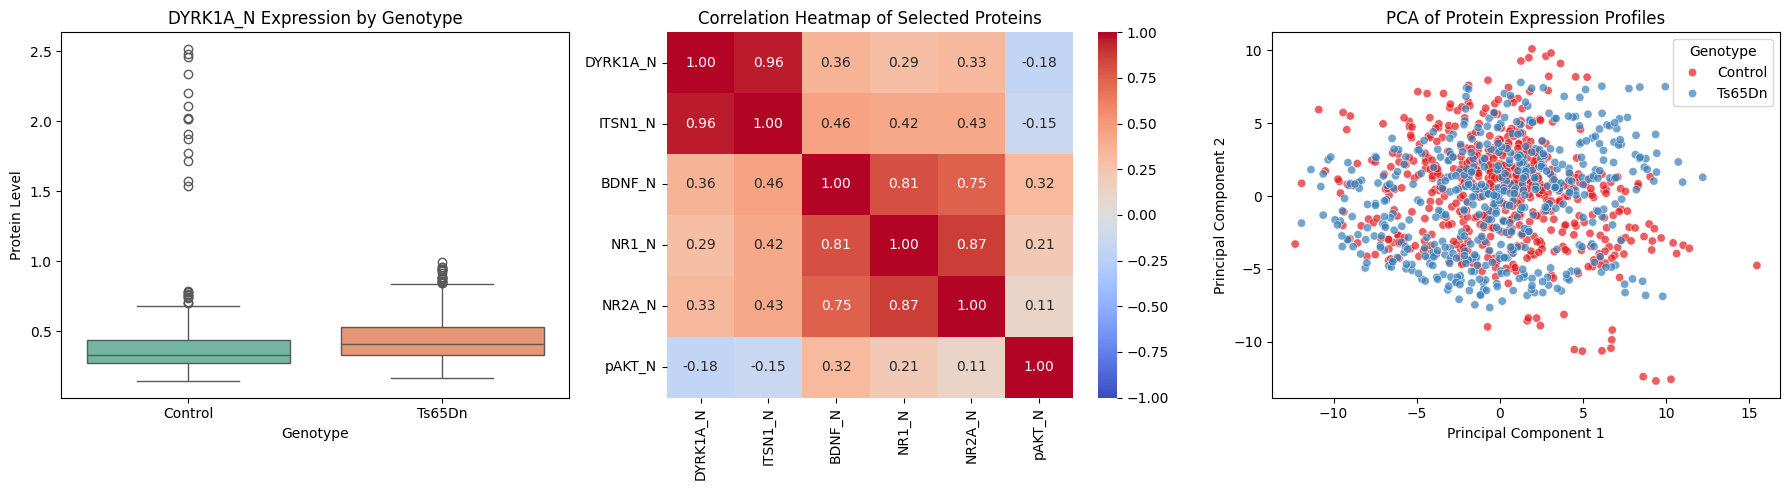

In [ ]:

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
if 'DYRK1A_N' in df.columns:
    sns.boxplot(data=df, x='Genotype', y='DYRK1A_N', palette='Set2')
    plt.title("DYRK1A_N Expression by Genotype")
    plt.ylabel("Protein Level")

plt.subplot(1, 3, 2)
subset_cols = protein_cols[:6]
sns.heatmap(df[subset_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap of Selected Proteins")

plt.subplot(1, 3, 3)
X_temp = SimpleImputer(strategy="median").fit_transform(df[protein_cols])
X_scaled = StandardScaler().fit_transform(X_temp)
pca_coords = PCA(n_components=2).fit_transform(X_scaled)

sns.scatterplot(x=pca_coords[:, 0], y=pca_coords[:, 1], hue=df['Genotype'], alpha=0.7, palette='Set1')
plt.title("PCA of Protein Expression Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

Biological Questions:
1. Boxplot: Does the expression of DYRK1A_N differ between Control and Ts65Dn?
  
  У групи з трисомією (Ts65Dn) медіана вища, але в контрольній групі є екстремальні викиди.

2. Heatmap: Are the expression levels of certain proteins highly correlated?

  Рівні деяких білків (наприклад, DYRK1A_N та ITSN1_N) мають майже ідеальну кореляцію (0.96), що вказує на їхню ймовірну спільну біологічну регуляцію.

3. Scatter plot: Do overall protein expression profiles cluster by genotype?

Чіткого розділення за генотипом немає. Класи на графіку сильно перемішані.



### C. Diagnostics

Check:

- missingness in the protein measurements and metadata;
- duplicate rows and duplicate MouseID-measurement records;
- whether every mouse has the expected number of repeated measurements;
- unusual categories or inconsistent labels;
- non-finite, negative, or otherwise implausible expression values;
- highly correlated or redundant protein variables;
- whether any candidate predictor is a deterministic part of the target.

In [ ]:
print("Missing values in metadata:")
print(df[metadata_cols].isna().sum())
missing_proteins = (df[protein_cols].isna().sum() > 0).sum()
print(f"Number of protein features with missing values: {missing_proteins}")
print()
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate MouseID records: {df.duplicated(subset=['MouseID']).sum()}")

print(f"\n Unique Number of Measurements per mouse: {df['Mouse_Unit'].value_counts().unique()}")



Missing values in metadata:
MouseID       0
Mouse_Unit    0
Genotype      0
Treatment     0
Behavior      0
class         0
dtype: int64
Number of protein features with missing values: 49

Exact duplicate rows: 0
Duplicate MouseID records: 0

 Unique Number of Measurements per mouse: [15]


In [ ]:
# Unusual Categories or Inconsistent Labels
for col in ['Genotype', 'Treatment', 'Behavior', 'class']:
    print(f"{col} unique values: {df[col].unique()}")



Genotype unique values: ['Control' 'Ts65Dn']
Treatment unique values: ['Memantine' 'Saline']
Behavior unique values: ['C/S' 'S/C']
class unique values: ['c-CS-m' 'c-SC-m' 'c-CS-s' 'c-SC-s' 't-CS-m' 't-SC-m' 't-CS-s' 't-SC-s']


In [ ]:
# Implausible Values
negative_vals = (df[protein_cols] < 0).sum().sum()
infinite_vals = np.isinf(df[protein_cols]).sum().sum()
print(f"Total negative protein values: {negative_vals}")
print(f"Total infinite protein values: {infinite_vals}")

Total negative protein values: 1
Total infinite protein values: 0


In [ ]:
df[protein_cols] = df[protein_cols].mask(df[protein_cols] < 0, np.nan)

In [ ]:
# Highly Correlated Proteins
corr_matrix = df[protein_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_correlated = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]
print(f"Number of proteins with Pearson correlation > 0.90: {len(highly_correlated)}")



Number of proteins with Pearson correlation > 0.90: 7


In [ ]:
# Target Leakage (Deterministic predictors)
leakage_check = pd.crosstab(df['class'], df['Genotype'])
print("Crosstab of 'class' vs 'Genotype':")
print(leakage_check)

Crosstab of 'class' vs 'Genotype':
Genotype  Control  Ts65Dn
class                    
c-CS-m        150       0
c-CS-s        135       0
c-SC-m        150       0
c-SC-s        135       0
t-CS-m          0     135
t-CS-s          0     105
t-SC-m          0     135
t-SC-s          0     135



### D. Preparation



Choose one supervised-learning problem and create:

    X
    y

Explain every variable that you exclude.

For a genotype-prediction question, start with the 77 protein measurements as candidate features. Exclude:

- MouseID, because it identifies the biological unit and can cause leakage;
- the target column;
- class when Genotype is the target, because it contains genotype information;
- Treatment and Behavior unless you explicitly want a conditional prediction question and can justify their use.

Use the real missing values in the dataset to compare a defensible removal rule with an imputation rule. If you impute, fit the imputer on the training data only and apply it to the test data.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer

cols_to_exclude = ['MouseID', 'Mouse_Unit', 'Genotype', 'class', 'Treatment', 'Behavior']
X_raw = df.drop(columns=cols_to_exclude)
y = df['Genotype']
groups = df['Mouse_Unit']

print(f"X shape: {X_raw.shape}, y shape: {y.shape}")


X shape: (1080, 77), y shape: (1080,)



### E. Split

Create an appropriate training/test split.

For generalization to unseen mice:

- group by MouseID;
- keep all 15 measurements from a mouse in the same partition;
- use a group-aware split such as GroupShuffleSplit or StratifiedGroupKFold when appropriate.

Explain:

- what population you want the model to generalize to;
  -  New, unseen mice.
- why a row-wise random split would give an over-optimistic estimate;

   - Data leakage. Since each mouse has 15 technical replicates, a random split puts measurements of the same mouse into both train and test sets. The model will memorize mice instead of learning biological patterns, artificially inflating the score.

- what the independent biological unit is;
    - The individual mouse ('Mouse_Unit')
- whether stratification is needed and whether it is compatible with your grouping strategy.

    - It is needed to keep the target classes (Genotype) balanced. It is fully compatible with grouping because a single mouse has the same genotype across all its 15 measurements.

In [ ]:
# Split BEFORE imputation to prevent data leakage
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X_raw, y, groups=groups))

X_train_raw, X_test_raw = X_raw.iloc[train_idx], X_raw.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train rows: {len(X_train_raw)} | Test rows: {len(X_test_raw)}")

Train rows: 810 | Test rows: 270


In [ ]:
# Strategy A: Removal (Dropping rows with any NaN)
X_train_dropped = X_train_raw.dropna()
rows_lost = len(X_train_raw) - len(X_train_dropped)
print(f"Lost {rows_lost} rows. Rows left: {len(X_train_dropped)}")


Lost 393 rows. Rows left: 417


In [ ]:
# Strategy B: Imputation (Median)
imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns)

print(f"Train NaNs after imputation = {X_train_imputed.isna().sum().sum()}")
print(f"Test NaNs after imputation = {X_test_imputed.isna().sum().sum()}")

Train NaNs after imputation = 0
Test NaNs after imputation = 0



### F. Confounding and distribution structure

Investigate associations between the target and:

- treatment;
- behavior;
- genotype;
- the composite class;
- the number of measurements per mouse.

Use cross-tabulations and plots to ask:

- are treatment and behavior balanced across genotype?
  - No. They are slightly inbalanced
- does the composite class encode the target directly?
  - Yes
- do some mice or experimental groups contribute different numbers of rows?
  - Each mouse contributes exactly 15 rows, but experimental groups no.
- could a model exploit experimental design structure instead of protein biology?
  - Yes, in case when MouseID  or  class  are included as features

Identify at least one plausible source of confounding, target leakage, or distribution shift.
  - MouseID or class if they are included as features

In [ ]:
pd.crosstab(df['Genotype'], df['Treatment'])

Treatment,Memantine,Saline
Genotype,,
Control,300,270
Ts65Dn,270,240


In [ ]:
pd.crosstab(df['Genotype'], df['Behavior'])

Behavior,C/S,S/C
Genotype,,
Control,285,285
Ts65Dn,240,270


In [ ]:
pd.crosstab(df['Genotype'], df['class'])

class,c-CS-m,c-CS-s,c-SC-m,c-SC-s,t-CS-m,t-CS-s,t-SC-m,t-SC-s
Genotype,,,,,,,,
Control,150,135,150,135,0,0,0,0
Ts65Dn,0,0,0,0,135,105,135,135


In [ ]:
print("Measurements per Experimental Group")
print(df.groupby('class')['MouseID'].count())

Measurements per Experimental Group
class
c-CS-m    150
c-CS-s    135
c-SC-m    150
c-SC-s    135
t-CS-m    135
t-CS-s    105
t-SC-m    135
t-SC-s    135
Name: MouseID, dtype: int64


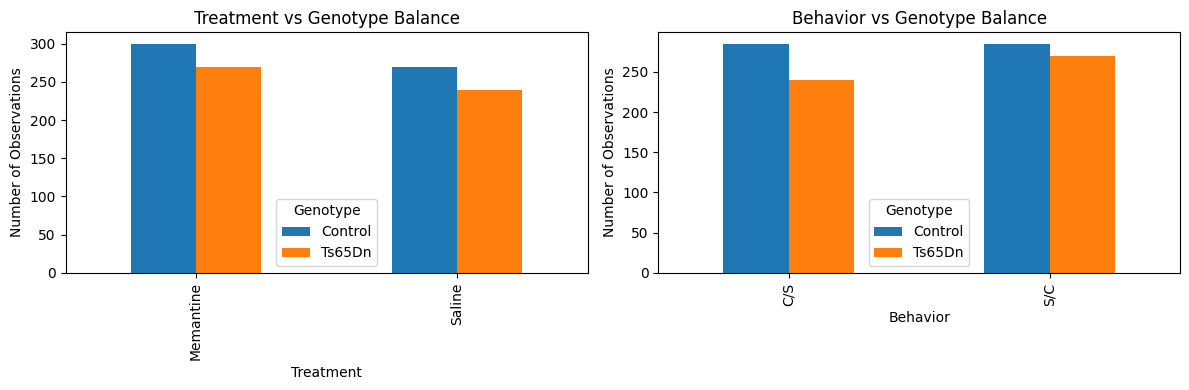

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df['Treatment'], df['Genotype']).plot(kind='bar', ax=axes[0])
axes[0].set_title("Treatment vs Genotype Balance")
axes[0].set_ylabel("Number of Observations")

pd.crosstab(df['Behavior'], df['Genotype']).plot(kind='bar', ax=axes[1])
axes[1].set_title("Behavior vs Genotype Balance")
axes[1].set_ylabel("Number of Observations")

plt.tight_layout()
plt.show()






### G. Deliverable

Provide:

- X_train, X_test, y_train, y_test;
- a table documenting the role of each column;
- a missingness report and a justified removal or imputation decision;
- plots if you want;
- a short Markdown interpretation describing:
  - the ML question;
  - the biological unit;
  - the split strategy;
  - one potential source of bias, confounding, or leakage.






#### Column Roles
| Column(s) | Role | Status in ML Pipeline |
| :--- | :--- | :--- |
| `DYRK1A_N` ... (77 proteins) | Numerical Features | Included in `X` |
| `Genotype` | Target Variable | Used as `y` |
| `MouseID`, `Mouse_Unit` | Identifiers / Biological Unit | Excluded (Grouping only) |
| `class` | Composite Class | Excluded (Target Leakage) |
| `Treatment`, `Behavior` | Experimental Metadata | Excluded (Not predicting conditional effects) |

#### Missingness Report & Decision
There are 49 protein features with missing values, but no completely empty rows. Dropping rows with missing values (Removal Strategy) would lead to an huge loss of biological data. Therefore, I chose **Median Imputation**. To prevent data leakage, the imputer was fitted strictly on the training set (`X_train`) and then used to transform both the training and test sets.

#### Short Interpretation
* **The ML question:** Can we predict the genotype (Control / Ts65Dn) of a mouse based solely on its protein expression profile?
* **The biological unit:** The individual mouse (Mouse_Unit), which has 15 repeated technical measurements.
* **The split strategy:** A group-aware split (GroupShuffleSplit) based on Mouse_Unit. This ensures all 15 measurements of a single mouse stay strictly in either the training or the test set, preventing the model from achieving artificially high performance by simply memorizing specific mice.
* **Potential source of bias/leakage:** The class metadata column is a direct source of target leakage and was excluded. Additionally, the slightly uneven number of mice across different experimental cohorts (ranging from 7 to 10 mice per group) acts as a potential confounder.


## Optional advanced task

Compare two evaluation questions:

1. a random row-wise train/test split;
2. a mouse-grouped train/test split.

Are these evaluating the same kind of generalization?

As a second extension, compare predicting Genotype with predicting the composite class. Which question is biologically clearer, and which variables must be excluded to avoid target leakage?